## XGBoost Model for Expected Attention

In [33]:
import pandas as pd
import numpy as np
from sklearn.model_selection import KFold
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [34]:
# load X_train and y_train
X_train = pd.read_csv("../outputs_csv/X_train.csv")
y_original = pd.read_csv("../outputs_csv/y_train.csv")
y_train = y_original["avg_attention_score"]

In [35]:
# implement cross validation using an 80-20 split.
# 5 folds means each validation fold is 20% of the data and each training fold is 80%.
N_SPLITS = 5
RANDOM_STATE = 42

if len(X_train) != len(y_train):
    raise ValueError(
        f"X_train and y_train must have the same number of rows. "
        f"Got {len(X_train)} and {len(y_train)}."
    )

kfold = KFold(n_splits=N_SPLITS, shuffle=True, random_state=RANDOM_STATE)

cv_folds = []
for fold_number, (train_idx, val_idx) in enumerate(kfold.split(X_train), start=1):
    cv_folds.append(
        {
            "fold": fold_number,
            "train_idx": train_idx,
            "val_idx": val_idx,
            "X_train_fold": X_train.iloc[train_idx],
            "X_val_fold": X_train.iloc[val_idx],
            "y_train_fold": y_train.iloc[train_idx],
            "y_val_fold": y_train.iloc[val_idx],
        }
    )

cv_summary = pd.DataFrame(
    [
        {
            "fold": fold["fold"],
            "train_rows": len(fold["train_idx"]),
            "validation_rows": len(fold["val_idx"]),
            "validation_pct": len(fold["val_idx"]) / len(X_train),
        }
        for fold in cv_folds
    ]
)

cv_summary

,fold,train_rows,validation_rows,validation_pct
0,1,24776,6195,0.200026
1,2,24777,6194,0.199994
2,3,24777,6194,0.199994
3,4,24777,6194,0.199994
4,5,24777,6194,0.199994


### Creating the Model

In [36]:
try:
    from xgboost import XGBRegressor
except ImportError as exc:
    raise ImportError(
        "xgboost is required for the model cells below. "
        "Install it in this notebook kernel before running these cells."
    ) from exc

N_MONTE_CARLO_SIMULATIONS = 10
MONTE_CARLO_SEEDS = [RANDOM_STATE + seed_offset for seed_offset in range(N_MONTE_CARLO_SIMULATIONS)]


def calculate_regression_metrics(y_true, y_pred):
    return {
        "rmse": np.sqrt(mean_squared_error(y_true, y_pred)),
        "mae": mean_absolute_error(y_true, y_pred),
        "r2": r2_score(y_true, y_pred),
    }


def evaluate_xgboost_monte_carlo(model_name, model_params, cv_folds, monte_carlo_seeds):
    fold_metrics = []

    for fold in cv_folds:
        simulation_predictions = []

        for seed in monte_carlo_seeds:
            model = XGBRegressor(**model_params, random_state=seed)
            model.fit(fold["X_train_fold"], fold["y_train_fold"])
            simulation_predictions.append(model.predict(fold["X_val_fold"]))

        averaged_predictions = np.mean(simulation_predictions, axis=0)
        metrics = calculate_regression_metrics(fold["y_val_fold"], averaged_predictions)
        metrics.update(
            {
                "model": model_name,
                "fold": fold["fold"],
                "num_simulations": len(monte_carlo_seeds),
                "mean_prediction_std": np.mean(np.std(simulation_predictions, axis=0)),
            }
        )
        fold_metrics.append(metrics)

    fold_metrics_df = pd.DataFrame(fold_metrics)
    summary = pd.DataFrame(
        [
            {
                "model": model_name,
                "num_simulations": len(monte_carlo_seeds),
                "mean_rmse": fold_metrics_df["rmse"].mean(),
                "std_rmse": fold_metrics_df["rmse"].std(),
                "mean_mae": fold_metrics_df["mae"].mean(),
                "std_mae": fold_metrics_df["mae"].std(),
                "mean_r2": fold_metrics_df["r2"].mean(),
                "std_r2": fold_metrics_df["r2"].std(),
                "mean_prediction_std": fold_metrics_df["mean_prediction_std"].mean(),
            }
        ]
    )

    return fold_metrics_df, summary

### Low-Variance XGBoost

In [37]:
low_variance_params = {
    "objective": "reg:squarederror",
    "eval_metric": "rmse",
    "n_estimators": 200,
    "learning_rate": 0.04,
    "max_depth": 2,
    "min_child_weight": 8,
    "gamma": 0.2,
    "subsample": 0.80,
    "colsample_bytree": 0.80,
    "reg_alpha": 0.10,
    "reg_lambda": 5.0,
    "tree_method": "hist",
    "n_jobs": -1,
    "verbosity": 0,
}

low_variance_fold_metrics, low_variance_summary = evaluate_xgboost_monte_carlo(
    model_name="low_variance_xgboost",
    model_params=low_variance_params,
    cv_folds=cv_folds,
    monte_carlo_seeds=MONTE_CARLO_SEEDS,
)

display(low_variance_fold_metrics)
low_variance_summary

,rmse,mae,r2,model,fold,num_simulations,mean_prediction_std
0,0.379941,0.291896,0.397578,low_variance_xgboost,1,10,0.004810
1,0.385138,0.299182,0.403800,low_variance_xgboost,2,10,0.004911
2,0.380147,0.293480,0.395226,low_variance_xgboost,3,10,0.004931
3,0.381226,0.293145,0.399081,low_variance_xgboost,4,10,0.004769
4,0.386563,0.296712,0.390587,low_variance_xgboost,5,10,0.004717


,model,num_simulations,mean_rmse,std_rmse,mean_mae,std_mae,mean_r2,std_r2,mean_prediction_std
0,low_variance_xgboost,10,0.382603,0.003046,0.294883,0.002989,0.397254,0.004869,0.004828


### Medium-Variance XGBoost

In [38]:
medium_variance_params = {
    "objective": "reg:squarederror",
    "eval_metric": "rmse",
    "n_estimators": 350,
    "learning_rate": 0.05,
    "max_depth": 4,
    "min_child_weight": 4,
    "gamma": 0.05,
    "subsample": 0.90,
    "colsample_bytree": 0.90,
    "reg_alpha": 0.02,
    "reg_lambda": 2.0,
    "tree_method": "hist",
    "n_jobs": -1,
    "verbosity": 0,
}

medium_variance_fold_metrics, medium_variance_summary = evaluate_xgboost_monte_carlo(
    model_name="medium_variance_xgboost",
    model_params=medium_variance_params,
    cv_folds=cv_folds,
    monte_carlo_seeds=MONTE_CARLO_SEEDS,
)

display(medium_variance_fold_metrics)
medium_variance_summary

,rmse,mae,r2,model,fold,num_simulations,mean_prediction_std
0,0.378021,0.290725,0.403651,medium_variance_xgboost,1,10,0.011774
1,0.384038,0.298089,0.407202,medium_variance_xgboost,2,10,0.011715
2,0.378303,0.291897,0.401080,medium_variance_xgboost,3,10,0.011750
3,0.379726,0.292305,0.403799,medium_variance_xgboost,4,10,0.011959
4,0.386175,0.296376,0.391808,medium_variance_xgboost,5,10,0.011742


,model,num_simulations,mean_rmse,std_rmse,mean_mae,std_mae,mean_r2,std_r2,mean_prediction_std
0,medium_variance_xgboost,10,0.381253,0.003656,0.293878,0.003175,0.401508,0.005842,0.011788


### High-Variance XGBoost

In [39]:
# high_variance_params = {
#     "objective": "reg:squarederror",
#     "eval_metric": "rmse",
#     "n_estimators": 500,
#     "learning_rate": 0.06,
#     "max_depth": 7,
#     "min_child_weight": 1,
#     "gamma": 0.0,
#     "subsample": 0.95,
#     "colsample_bytree": 0.95,
#     "reg_alpha": 0.0,
#     "reg_lambda": 0.5,
#     "tree_method": "hist",
#     "n_jobs": -1,
#     "verbosity": 0,
# }

# high_variance_fold_metrics, high_variance_summary = evaluate_xgboost_monte_carlo(
#     model_name="high_variance_xgboost",
#     model_params=high_variance_params,
#     cv_folds=cv_folds,
#     monte_carlo_seeds=MONTE_CARLO_SEEDS,
# )

# display(high_variance_fold_metrics)
# high_variance_summary

### Model Comparison

In [40]:
# model_comparison = (
#     pd.concat(
#         [low_variance_summary, medium_variance_summary, high_variance_summary],
#         ignore_index=True,
#     )
#     .sort_values(["mean_rmse", "mean_mae", "mean_r2"], ascending=[True, True, False])
#     .reset_index(drop=True)
# )

# best_model_name = model_comparison.loc[0, "model"]
# print(f"Best model by mean validation RMSE: {best_model_name}")

# model_comparison

In [41]:
# Use the medium-variance XGBoost profile to generate out-of-fold expected attention.
# Gravity = actual attention - expected attention.
def predict_expected_attention_monte_carlo_cv(model_params, cv_folds, monte_carlo_seeds, num_rows):
    expected_attention = np.full(num_rows, np.nan)

    for fold in cv_folds:
        simulation_predictions = []

        for seed in monte_carlo_seeds:
            model = XGBRegressor(**model_params, random_state=seed)
            model.fit(fold["X_train_fold"], fold["y_train_fold"])
            simulation_predictions.append(model.predict(fold["X_val_fold"]))

        expected_attention[fold["val_idx"]] = np.mean(simulation_predictions, axis=0)

    if np.isnan(expected_attention).any():
        raise ValueError("Some rows did not receive expected_attention predictions.")

    return expected_attention


y_train_with_players = pd.read_csv("../outputs_csv/y_train.csv")
gravity_dataset = y_train_with_players.copy()
gravity_dataset["expected_attention"] = predict_expected_attention_monte_carlo_cv(
    model_params=medium_variance_params,
    cv_folds=cv_folds,
    monte_carlo_seeds=MONTE_CARLO_SEEDS,
    num_rows=len(X_train),
)
gravity_dataset["gravity_score"] = (
    gravity_dataset["avg_attention_score"] - gravity_dataset["expected_attention"]
)

gravity_dataset.head()

,avg_attention_score,nflId,rusher_name,officialPosition,expected_attention,gravity_score
0,0.461538,41263,Demarcus Lawrence,DE,0.904706,-0.443167
1,0.615385,42403,Randy Gregory,DE,0.368581,0.246803
2,1.307692,44955,Carlos Watkins,DE,1.218276,0.089416
3,1.000000,53441,Micah Parsons,OLB,1.141261,-0.141261
4,0.615385,53504,Osa Odighizuwa,DT,1.118670,-0.503285


### Gravity Scores for Selected Players

In [42]:
selected_players = ["Myles Garrett", "Aaron Donald", "Justin Hollins"]

selected_player_gravity = (
    gravity_dataset[gravity_dataset["rusher_name"].isin(selected_players)]
    .groupby("nflId", as_index=False)
    .agg(
        rusher_name=("rusher_name", "first"),
        num_rows=("gravity_score", "size"),
        actual_attention=("avg_attention_score", "mean"),
        expected_attention=("expected_attention", "mean"),
        gravity_score=("gravity_score", "mean"),
    )
    .sort_values("gravity_score", ascending=False)
    .reset_index(drop=True)
)

selected_player_gravity

,nflId,rusher_name,num_rows,actual_attention,expected_attention,gravity_score
0,41239,Aaron Donald,229,1.590982,1.362093,0.228889
1,44813,Myles Garrett,170,1.084141,0.978004,0.106137
2,47939,Justin Hollins,64,0.728201,0.836464,-0.108263


### Top 20 Gravity Scores

In [43]:
top_20_gravity_scores = (
    gravity_dataset
    .groupby("nflId", as_index=False)
    .agg(
        rusher_name=("rusher_name", "first"),
        num_rows=("gravity_score", "size"),
        actual_attention=("avg_attention_score", "mean"),
        expected_attention=("expected_attention", "mean"),
        gravity_score=("gravity_score", "mean"),
    )
    .query("num_rows >= 75")
    .sort_values("gravity_score", ascending=False)
    .head(20)
    .reset_index(drop=True)
)

top_20_gravity_scores

,nflId,rusher_name,num_rows,actual_attention,expected_attention,gravity_score
0,41239,Aaron Donald,229,1.590982,1.362093,0.228889
1,53467,Christian Barmore,165,1.612486,1.456215,0.156271
2,37097,Cameron Jordan,197,1.122000,0.993966,0.128034
3,43441,Matt Ioannidis,122,1.522077,1.407333,0.114744
4,38544,Michael Brockers,108,1.508740,1.396328,0.112412
5,47785,Nick Bosa,138,1.059147,0.952817,0.106330
6,44813,Myles Garrett,170,1.084141,0.978004,0.106137
7,42480,Grady Jarrett,159,1.541059,1.446504,0.094555
8,53457,Payton Turner,77,1.202520,1.110319,0.092200
9,39959,Sheldon Richardson,109,1.521554,1.430948,0.090606


In [44]:
top_20_gravity_scores = (
    gravity_dataset
    .groupby("nflId", as_index=False)
    .agg(
        rusher_name=("rusher_name", "first"),
        num_rows=("gravity_score", "size"),
        actual_attention=("avg_attention_score", "mean"),
        expected_attention=("expected_attention", "mean"),
        gravity_score=("gravity_score", "mean"),
    )
    .query("num_rows >= 75")
    .sort_values("gravity_score", ascending=False)
    .tail(20)
    .reset_index(drop=True)
)

top_20_gravity_scores

,nflId,rusher_name,num_rows,actual_attention,expected_attention,gravity_score
0,46146,Sam Hubbard,198,0.947063,1.000594,-0.053531
1,40051,Alex Okafor,103,0.937559,0.994744,-0.057185
2,47802,Jeffery Simmons,224,1.363899,1.430387,-0.066488
3,40042,Brandon Williams,80,1.384607,1.453509,-0.068902
4,52665,Malcolm Roach,77,1.383572,1.453401,-0.069830
5,46082,Daron Payne,202,1.349734,1.419806,-0.070072
6,44877,Larry Ogunjobi,178,1.409286,1.480602,-0.071317
7,40171,Nicholas Williams,112,1.383278,1.455491,-0.072213
8,41786,Kerry Hyder,155,1.258736,1.334786,-0.076050
9,37841,Mario Addison,94,0.916008,0.999500,-0.083492


### Making Visualizations

In [51]:
all_rushers_75plus = gravity_dataset.groupby("nflId", as_index=False).agg(
        rusher_name=("rusher_name", "first"),
        officialPosition=("officialPosition", "first"),
        num_rows=("gravity_score", "size"),
        actual_attention=("avg_attention_score", "mean"),
        expected_attention=("expected_attention", "mean"),
        gravity_score=("gravity_score", "mean"),).query("num_rows >= 75").reset_index(drop=True).rename(columns={"officialPosition": "rusher_position"})


In [52]:
all_rushers_75plus

,nflId,rusher_name,rusher_position,num_rows,actual_attention,expected_attention,gravity_score
0,33131,Calais Campbell,DE,169,1.492736,1.408923,0.083812
1,35441,Ndamukong Suh,DE,183,1.369480,1.396881,-0.027400
2,35454,Jason Pierre-Paul,DE,155,1.023155,1.032828,-0.009673
3,35470,Jerry Hughes,DE,105,0.901375,1.028638,-0.127263
4,35485,Linval Joseph,NT,100,1.429980,1.433986,-0.004006
...,...,...,...,...,...,...,...
161,53467,Christian Barmore,DT,165,1.612486,1.456215,0.156271
162,53479,Azeez Ojulari,OLB,145,0.959971,1.003927,-0.043956
163,53504,Osa Odighizuwa,DT,154,1.425084,1.385897,0.039188
164,53540,Cameron Sample,DE,114,1.146652,1.142175,0.004476


Merge with PFF position labels (DI vs ED)

In [53]:
pff_2021 = pd.read_csv("../cleaned_csv/pff_position_data.csv")
pff_2021

,player,player_id,position,team_name,player_game_count,assists,batted_passes,catch_rate,declined_penalties,forced_fumbles,...,snap_counts_slot,stops,tackles,tackles_for_loss,targets,total_pressures,touchdowns,yards,yards_after_catch,yards_per_reception
0,DeSean Jackson,4363,WR,LV,1,0,0,NaN,0,0,...,0,0,0,0,0,0,0,0,0,NaN
1,Calais Campbell,4364,DI,BLT,15,12,1,NaN,1,0,...,0,24,34,6,0,31,0,0,0,NaN
2,Matthew Slater,4467,WR,NE,1,0,0,NaN,0,0,...,0,0,0,0,0,0,0,0,0,NaN
3,Malcolm Jenkins,4937,S,NO,16,17,0,70.4,0,1,...,226,27,65,2,54,5,2,348,164,9.2
4,Jason McCourty,5127,S,MIA,7,5,0,71.4,0,0,...,25,3,16,0,14,0,1,98,29,9.8
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1112,Nahshon Wright,100412,CB,DAL,5,0,0,62.5,1,0,...,3,1,5,0,8,0,0,81,10,16.2
1113,Daniel Archibong,100963,DI,PIT,2,1,0,NaN,0,0,...,0,0,1,0,0,0,0,0,0,NaN
1114,Jarren Williams,101750,CB,NYG,5,2,0,47.1,0,0,...,46,5,14,0,17,0,1,64,19,8.0
1115,Michael Hoecht,108840,DI,LA,12,0,0,NaN,0,0,...,0,3,4,0,0,2,0,0,0,NaN


In [54]:
import pandas as pd
import re

# --------------------------------------------------
# 1. Helper: keep only the first two words of a name
#    Example:
#    "Lawrence Guy Sr." -> "lawrence guy"
#    "Takkarist McKinley" -> "takkarist mckinley"
# --------------------------------------------------
def first_two_words(name):
    if pd.isna(name):
        return None
    name = str(name).strip()
    if not name:
        return None

    # collapse repeated whitespace
    name = re.sub(r"\s+", " ", name)

    # keep only first two words
    words = name.split(" ")[:2]

    return " ".join(words).lower()


# --------------------------------------------------
# 2. Helper: compact version for containment matching
#    Example:
#    "Lawrence Guy" -> "lawrenceguy"
#    "Takk McKinley" -> "takkmckinley"
# --------------------------------------------------
def compact_name(name):
    if pd.isna(name):
        return None
    name = str(name).lower()

    # keep only letters/numbers, remove spaces/punctuation
    name = re.sub(r"[^a-z0-9]", "", name)

    return name if name else None


# --------------------------------------------------
# 3. Position mapping:
#    pff_2021['position'] -> allowed df['rusher_position']
# --------------------------------------------------
position_map = {
    "DI": ["DE", "DT", "NT"],
    "ED": ["DE", "OLB"],
    "LB": ["OLB", "ILB"]
}


# --------------------------------------------------
# 4. Make working copies
# --------------------------------------------------
df_work = all_rushers_75plus.copy().reset_index(drop=False).rename(columns={"index": "_row_id"})
pff_work = pff_2021[["player", "position", "team_name"]].copy()


# --------------------------------------------------
# 5. Normalize names in both dataframes
# --------------------------------------------------
df_work["rusher_name_2w"] = df_work["rusher_name"].apply(first_two_words)
df_work["rusher_name_compact"] = df_work["rusher_name_2w"].apply(compact_name)

pff_work["player_2w"] = pff_work["player"].apply(first_two_words)
pff_work["player_compact"] = pff_work["player_2w"].apply(compact_name)


# --------------------------------------------------
# 6. Expand PFF positions so each row has one allowed
#    df rusher position it can match to
# --------------------------------------------------
pff_work["allowed_rusher_position"] = pff_work["position"].map(position_map)
pff_expanded = pff_work.explode("allowed_rusher_position").reset_index(drop=True)


# --------------------------------------------------
# 7. Merge on position first
#    This gives candidate matches only where the custom
#    position logic is satisfied
# --------------------------------------------------
candidates = df_work.merge(
    pff_expanded,
    how="left",
    left_on="rusher_position",
    right_on="allowed_rusher_position",
    suffixes=("", "_pff")
)


# --------------------------------------------------
# 8. Apply custom name matching
#
#    A match is TRUE if:
#    (a) first two words are exactly equal
#        OR
#    (b) word-by-word subsequence matching works in either direction
#
#    This handles:
#    "Lawrence Guy Sr." vs "Lawrence Guy"
#    "Takkarist McKinley" vs "Takk McKinley"
# --------------------------------------------------
def is_subsequence(small, big):
    """
    Return True if every character in `small` appears in `big`
    in the same left-to-right order (not necessarily contiguously).
    Example:
        'takk' in-order within 'takkarist' -> True
    """
    if small is None or big is None:
        return False

    i = 0
    for ch in big:
        if i < len(small) and ch == small[i]:
            i += 1
    return i == len(small)


def names_match_two_word_logic(name1, name2):
    """
    Compare the first two words of each normalized name.
    Match if:
      1) exact equality, OR
      2) each corresponding word matches by subsequence in either direction
    """
    if pd.isna(name1) or pd.isna(name2):
        return False

    name1 = str(name1).strip().lower()
    name2 = str(name2).strip().lower()

    if not name1 or not name2:
        return False

    # exact match on the normalized first-two-word strings
    if name1 == name2:
        return True

    words1 = name1.split()
    words2 = name2.split()

    # require same number of words after first_two_words normalization
    if len(words1) != len(words2):
        return False

    # each corresponding word must match by subsequence in either direction
    for w1, w2 in zip(words1, words2):
        if not (is_subsequence(w1, w2) or is_subsequence(w2, w1)):
            return False

    return True


candidates["name_match"] = candidates.apply(
    lambda x: names_match_two_word_logic(x["rusher_name_2w"], x["player_2w"]),
    axis=1
)

# Keep only rows where the custom name rule matched
matched = candidates[candidates["name_match"]].copy()


# --------------------------------------------------
# 9. If multiple PFF rows match the same df row,
#    choose the best one:
#    - exact two-word match beats containment match
#    - then smaller compact-name length difference wins
# --------------------------------------------------
matched["match_score"] = 1
matched.loc[matched["rusher_name_2w"] == matched["player_2w"], "match_score"] = 2

matched["length_diff"] = (
    matched["rusher_name_compact"].str.len()
    - matched["player_compact"].str.len()
).abs()

best_match = (
    matched.sort_values(
        by=["_row_id", "match_score", "length_diff"],
        ascending=[True, False, True]
    )
    .drop_duplicates(subset="_row_id", keep="first")
    [["_row_id", "player", "position", "team_name"]]
)


# --------------------------------------------------
# 10. Merge the selected PFF columns back into df
# --------------------------------------------------
df_merged = df_work.merge(best_match, on="_row_id", how="left")


# --------------------------------------------------
# 11. Drop helper columns if you do not want them
# --------------------------------------------------
df_merged = df_merged.drop(
    columns=["_row_id", "rusher_name_2w", "rusher_name_compact"]
)

# df_merged is your final dataframe

In [55]:
df_merged[df_merged["position"].isna()]

,nflId,rusher_name,rusher_position,num_rows,actual_attention,expected_attention,gravity_score,player,position,team_name
30,40171,Nicholas Williams,DE,112,1.383278,1.455491,-0.072213,NaN,NaN,NaN
145,52479,Justin Madubuike,DT,75,1.411025,1.415106,-0.004082,NaN,NaN,NaN
149,52585,Michael Danna,DE,137,1.004988,1.041636,-0.036648,NaN,NaN,NaN


In [58]:
# Handle outliers
df_merged.loc[
    df_merged["rusher_name"] == "Michael Danna",
    ["player", "position", "team_name"]
] = (
    pff_expanded.loc[
        pff_expanded["player"] == "Mike Danna",
        ["player", "position", "team_name"]
    ].iloc[0].values
)

df_merged.loc[
    df_merged["rusher_name"] == "Nicholas Williams",
    ["player", "position", "team_name"]
] = (
    pff_expanded.loc[
        pff_expanded["player"] == "Nick Williams",
        ["player", "position", "team_name"]
    ].iloc[0].values
)

df_merged.loc[
    df_merged["rusher_name"] == "Justin Madubuike",
    ["player", "position", "team_name"]
] = (
    pff_expanded.loc[
        pff_expanded["player"] == "Nnamdi Madubuike",
        ["player", "position", "team_name"]
    ].iloc[0].values
)




In [ ]:
# ensure there are no null values.

df_merged.isna().sum()

nflId                 0
rusher_name           0
rusher_position       0
num_rows              0
actual_attention      0
expected_attention    0
gravity_score         0
player                0
position              0
team_name             0
dtype: int64

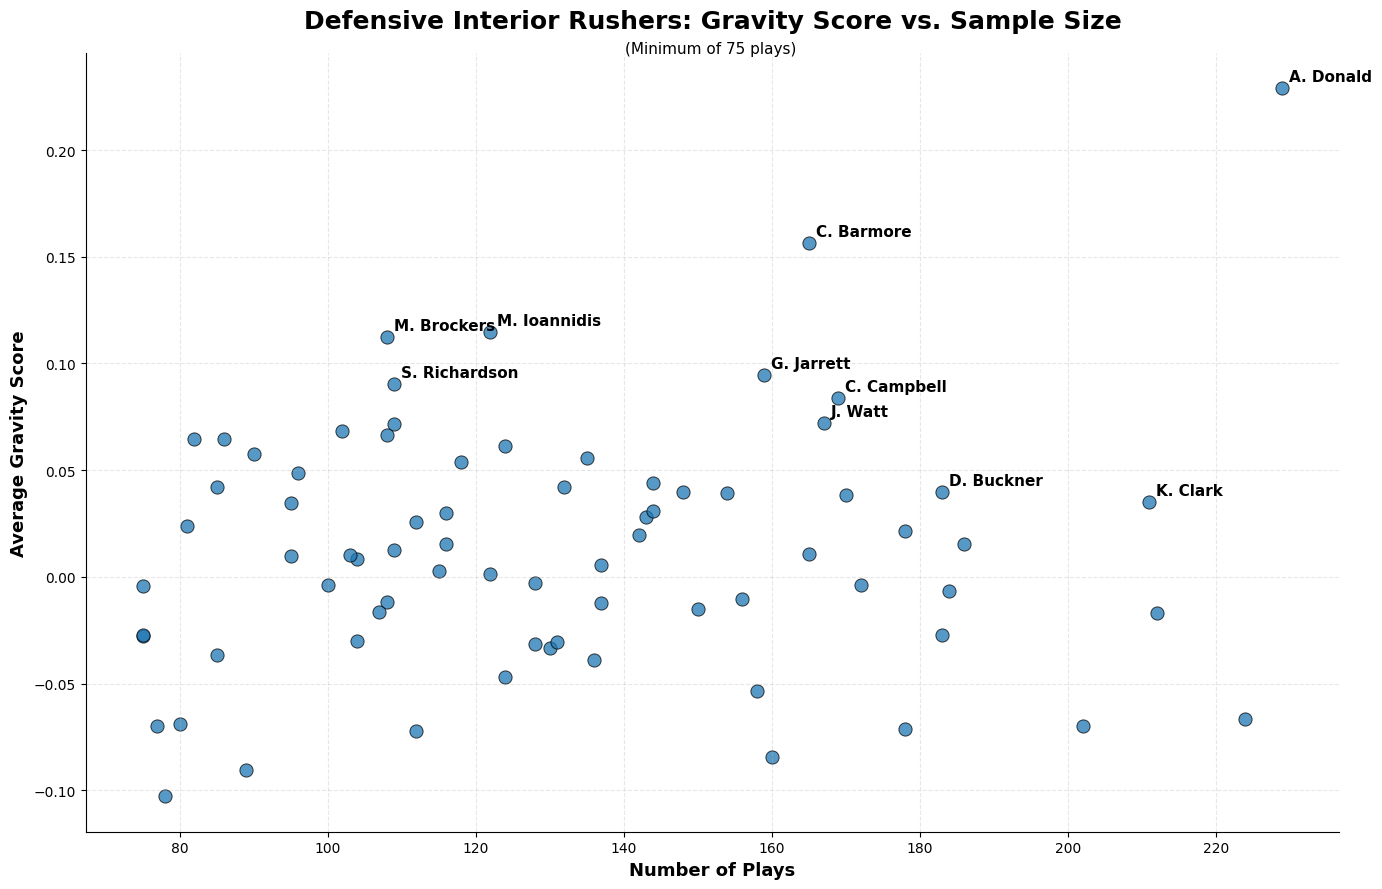

In [80]:
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

# --------------------------------------------
# 1. Filter to DI rushers and keep needed cols
# --------------------------------------------
plot_df = (
    df_merged[df_merged["position"] == "DI"][
        ["rusher_name", "num_rows", "gravity_score"]
    ]
    .dropna(subset=["rusher_name", "num_rows", "gravity_score"])
    .copy()
)

# --------------------------------------------
# 2. Get top 8 by gravity_score
# --------------------------------------------
top_8 = (
    plot_df.sort_values("gravity_score", ascending=False)
    .head(8)
    .copy()
)

# --------------------------------------------
# 3. Create Big Data Bowl-style scatter plot
# --------------------------------------------
fig, ax = plt.subplots(figsize=(14, 9))

# Main scatter
ax.scatter(
    plot_df["num_rows"],
    plot_df["gravity_score"],
    s=90,
    alpha=0.75,
    edgecolors="black",
    linewidths=0.7,
    color="tab:blue"
)

# # Highlight top 8 with same color, just bigger
# ax.scatter(
#     top_8["num_rows"],
#     top_8["gravity_score"],
#     s=150,
#     alpha=0.75,
#     edgecolors="black",
#     linewidths=1.0,
#     color="tab:blue",
#     zorder=3
# )

# --------------------------------------------
# 4. Add labels
#    - label top 8
#    - also force labels for specific players
# --------------------------------------------
forced_labels = {
    "Kenny Clark",
    "DeForest Buckner",
}

top_8_names = set(top_8["rusher_name"])
label_names = top_8_names | forced_labels

label_df = plot_df[plot_df["rusher_name"].isin(label_names)].copy()

for _, row in label_df.iterrows():
    first_name, *rest = row["rusher_name"].split()
    abbreviated_name = f"{first_name[0]}. {' '.join(rest)}"

    ax.annotate(
        abbreviated_name,
        xy=(row["num_rows"], row["gravity_score"]),
        xytext=(5, 5),
        textcoords="offset points",
        fontsize=11,
        fontweight="bold"
    )

# --------------------------------------------
# 5. Styling
# --------------------------------------------
ax.set_title(
    "Defensive Interior Rushers: Gravity Score vs. Sample Size",
    fontsize=18,
    fontweight="bold",
    pad=18
)

ax.set_xlabel("Number of Plays", fontsize=13, fontweight="bold")
ax.set_ylabel("Average Gravity Score", fontsize=13, fontweight="bold")

ax.grid(True, linestyle="--", alpha=0.3)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

fig.text(
    0.45,
    0.934,
    "(Minimum of 75 plays)",
    fontsize=11
)

plt.tight_layout()

output_dir = Path("../../Gravity Visualizations")
output_dir.mkdir(parents=True, exist_ok=True)
fig.savefig(output_dir / "defensive_interior_gravity_score_vs_sample_size.png", dpi=300, bbox_inches="tight")

plt.show()

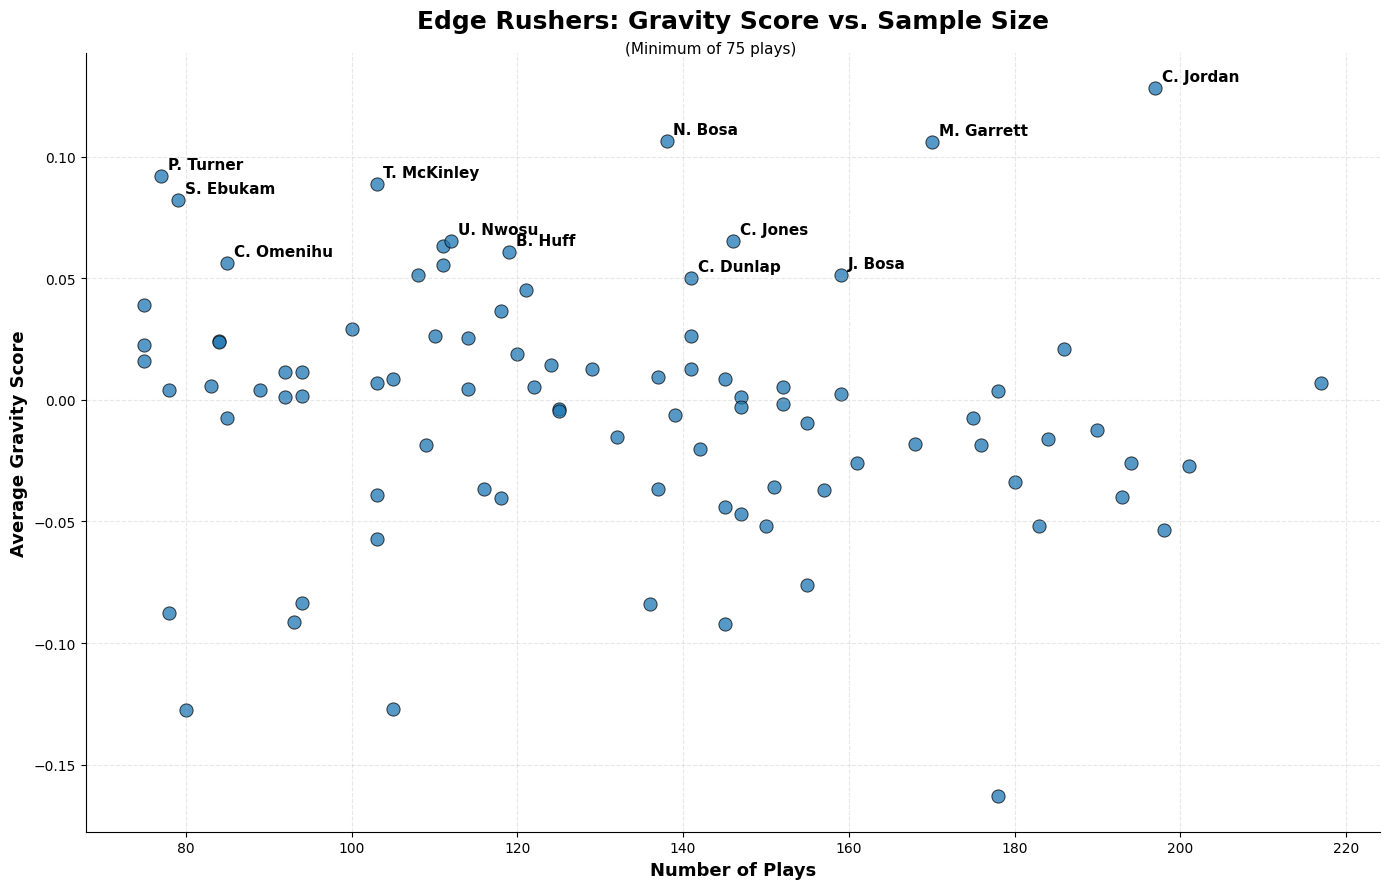

In [81]:
# edge rushers
from pathlib import Path

# --------------------------------------------
# 1. Filter to DI rushers and keep needed cols
# --------------------------------------------
plot_df = (
    df_merged[df_merged["position"] == "ED"][
        ["rusher_name", "num_rows", "gravity_score"]
    ]
    .dropna(subset=["rusher_name", "num_rows", "gravity_score"])
    .copy()
)

# --------------------------------------------
# 2. Get top 8 by gravity_score
# --------------------------------------------
top_8 = (
    plot_df.sort_values("gravity_score", ascending=False)
    .head(8)
    .copy()
)

# --------------------------------------------
# 3. Create Big Data Bowl-style scatter plot
# --------------------------------------------
fig, ax = plt.subplots(figsize=(14, 9))

# Main scatter
ax.scatter(
    plot_df["num_rows"],
    plot_df["gravity_score"],
    s=90,
    alpha=0.75,
    edgecolors="black",
    linewidths=0.7,
    color="tab:blue"
)

# # Highlight top 8 with same color, just bigger
# ax.scatter(
#     top_8["num_rows"],
#     top_8["gravity_score"],
#     s=150,
#     alpha=0.75,
#     edgecolors="black",
#     linewidths=1.0,
#     color="tab:blue",
#     zorder=3
# )

# --------------------------------------------
# 4. Add labels
#    - label top 8
#    - also force labels for specific players
# --------------------------------------------
forced_labels = {
    "Bryce Huff",
    "Charles Omenihu",
    "Joey Bosa",
    "Carlos Dunlap",
    
    
}

top_8_names = set(top_8["rusher_name"])
label_names = top_8_names | forced_labels

label_df = plot_df[plot_df["rusher_name"].isin(label_names)].copy()

for _, row in label_df.iterrows():
    first_name, *rest = row["rusher_name"].split()
    abbreviated_name = f"{first_name[0]}. {' '.join(rest)}"

    ax.annotate(
        abbreviated_name,
        xy=(row["num_rows"], row["gravity_score"]),
        xytext=(5, 5),
        textcoords="offset points",
        fontsize=11,
        fontweight="bold"
    )

# --------------------------------------------
# 5. Styling
# --------------------------------------------
ax.set_title(
    "Edge Rushers: Gravity Score vs. Sample Size",
    fontsize=18,
    fontweight="bold",
    pad=18
)

ax.set_xlabel("Number of Plays", fontsize=13, fontweight="bold")
ax.set_ylabel("Average Gravity Score", fontsize=13, fontweight="bold")

ax.grid(True, linestyle="--", alpha=0.3)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

fig.text(
    0.45,
    0.934,
    "(Minimum of 75 plays)",
    fontsize=11
)

plt.tight_layout()

output_dir = Path("../../Gravity Visualizations")
output_dir.mkdir(parents=True, exist_ok=True)
fig.savefig(output_dir / "edge_rushers_gravity_score_vs_sample_size.png", dpi=300, bbox_inches="tight")

plt.show()

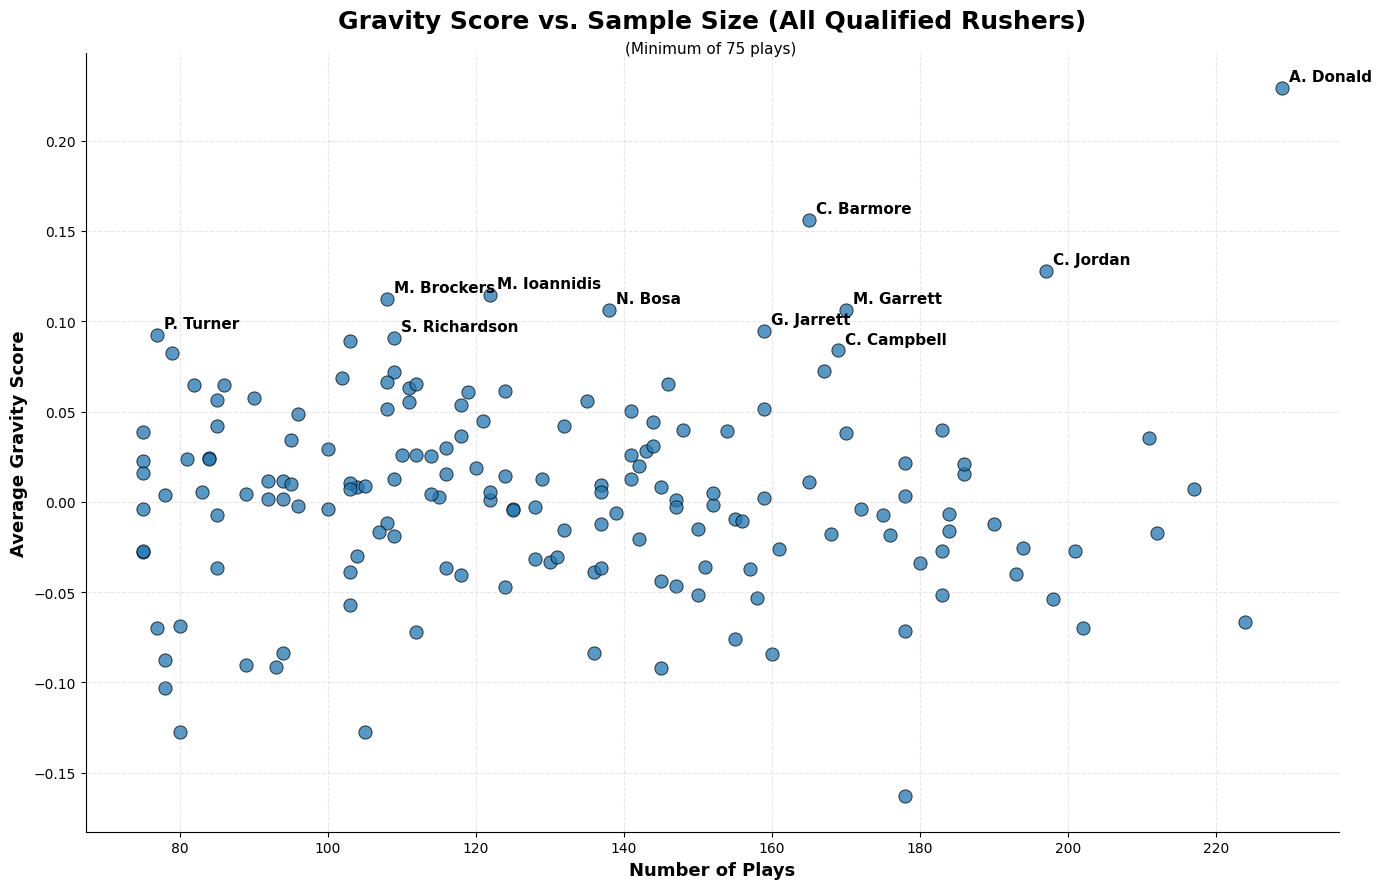

In [82]:
# all qualified rushers
from pathlib import Path

# --------------------------------------------
# 1. Filter to DI rushers and keep needed cols
# --------------------------------------------
plot_df = (
    df_merged[
        ["rusher_name", "num_rows", "gravity_score"]
    ]
    .dropna(subset=["rusher_name", "num_rows", "gravity_score"])
    .copy()
)

# --------------------------------------------
# 2. Get top 12 by gravity_score
# --------------------------------------------
top_12 = (
    plot_df.sort_values("gravity_score", ascending=False)
    .head(12)
    .copy()
)

# --------------------------------------------
# 3. Create Big Data Bowl-style scatter plot
# --------------------------------------------
fig, ax = plt.subplots(figsize=(14, 9))

# Main scatter
ax.scatter(
    plot_df["num_rows"],
    plot_df["gravity_score"],
    s=90,
    alpha=0.75,
    edgecolors="black",
    linewidths=0.7,
    color="tab:blue"
)

# # Highlight top 12 with same color, just bigger
# ax.scatter(
#     top_12["num_rows"],
#     top_12["gravity_score"],
#     s=150,
#     alpha=0.75,
#     edgecolors="black",
#     linewidths=1.0,
#     color="tab:blue",
#     zorder=3
# )

# --------------------------------------------
# 4. Add labels
#    - label top 12 EXCEPT Takkarist McKinley
#    - also force labels for specific players
# --------------------------------------------


# forced_labels = {
#     "Kenny Clark",
#     "DeForest Buckner", 
# }

top_12_names = set(top_12["rusher_name"])
excluded_names = {"Takkarist McKinley"}
label_names = (top_12_names - excluded_names)

label_df = plot_df[plot_df["rusher_name"].isin(label_names)].copy()

for _, row in label_df.iterrows():
    first_name, *rest = row["rusher_name"].split()
    abbreviated_name = f"{first_name[0]}. {' '.join(rest)}"

    ax.annotate(
        abbreviated_name,
        xy=(row["num_rows"], row["gravity_score"]),
        xytext=(5, 5),
        textcoords="offset points",
        fontsize=11,
        fontweight="bold"
    )

# --------------------------------------------
# 5. Styling
# --------------------------------------------
ax.set_title(
    "Gravity Score vs. Sample Size (All Qualified Rushers)",
    fontsize=18,
    fontweight="bold",
    pad=18
)

ax.set_xlabel("Number of Plays", fontsize=13, fontweight="bold")
ax.set_ylabel("Average Gravity Score", fontsize=13, fontweight="bold")

ax.grid(True, linestyle="--", alpha=0.3)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

fig.text(
    0.45,
    0.934,
    "(Minimum of 75 plays)",
    fontsize=11
)

plt.tight_layout()

output_dir = Path("../../Gravity Visualizations")
output_dir.mkdir(parents=True, exist_ok=True)
fig.savefig(output_dir / "all_qualified_rushers_gravity_score_vs_sample_size.png", dpi=300, bbox_inches="tight")

plt.show()
